# Hybrid searching을 활용한 RAG 챗봇 고도화

### 실습 목표

이 실습은 RAG(Retrieval-Augmented Generation) 과정에서 Dense(Ollama 임베딩 기반)와 Sparse(BM25 기반) 검색을 모두 경험해보고, 두 검색 결과를 결합한 후 HuggingFace Cross Encoder 기반의 재정렬(Reranking)을 적용하여 최종적으로 RAG 챗봇의 답변 품질을 향상시키는 방법을 학습하는 데 목적이 있습니다.

### 실습 목차
1. 문서 로드 및 전처리 (PDF 파일 로드 및 청크 분할)
2. Dense Retrieval (Ollama 임베딩 기반)
3. Sparse Retrieval (BM25 기반)
4. 두 검색 결과 결합 및 Cross Encoder Reranking
5. RAG 챗봇 워크플로우 구성 및 실행

### 0. 환경 설정

필요한 라이브러리를 아래와 같이 불러옵니다.

In [1]:
import os
from time import time
from typing import List

from dotenv import load_dotenv
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_chroma import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
from typing_extensions import TypedDict

load_dotenv()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_5496/3922856151.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder


True

참고: 이 노트북은 실습1에서 이미 설치한 Ollama `qwen3-embedding:0.6b` 임베딩 모델을 Dense 검색에 재사용하고, 답변 생성에는 ChatGPT API(`.env`의 `MODEL_NAME`)를 사용합니다.

* `llm` : 검색된 문서를 바탕으로 최종 답변을 생성하는 모델
* `route_llm` : RAG 사용 여부를 JSON으로 판단하는 라우팅 전용 모델 (`llm`에 JSON 출력 모드를 추가한 것)

In [2]:
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
# llm.bind(...)로 JSON 강제 출력 옵션을 추가해 route_llm을 만듭니다. (동일 모델, 다른 출력 형식)
route_llm = llm.bind(response_format={"type": "json_object"})

### 1. 문서 로드 및 전처리
- PDF 문서 로드 및 청크 분할:
지정된 데이터 경로의 PDF 파일을 `PyPDFLoader`로 불러오고, `RecursiveCharacterTextSplitter`를 이용해 청크 크기 500, 겹침 100으로 분할합니다.

In [3]:
# 데이터 경로 및 문서 파일명 지정
data_dir = "data"
pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"

# PDF 문서 로드
loader = PyPDFLoader(os.path.join(data_dir, pdf_data_name))
docs = loader.load()

# 텍스트 분할: 청크 크기 500, 겹침 100
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = text_splitter.split_documents(docs)

print(f"총 Document 개수: {len(docs)}")

총 Document 개수: 51


### 2. Dense Retrieval (Ollama 임베딩 기반)
- 임베딩 벡터 DB 구축:
`OllamaEmbeddings`를 사용하여 Dense 임베딩을 생성한 후, Chroma 벡터 스토어에 저장합니다. 임베딩 생성 소요시간을 측정하여 출력합니다.
- Dense 검색 실행:
생성된 벡터 스토어에서 쿼리("프런티어 모델 포럼에 대해 설명해")에 대해 상위 5개의 문서를 `similarity_search_with_score`를 통해 회수하고, 각 문서의 유사도 점수를 출력합니다.

In [4]:
print("=== Step 1: Dense Retrieval (Ollama Embedding) ===")

# Ollama 임베딩을 활용해 벡터 DB 구축 (Chroma 사용)
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

persist_dir = "./vectorstore/dense"
# 이미 임베딩된 벡터스토어가 있으면 그대로 불러오고, 없으면 새로 임베딩해서 저장합니다.
if os.path.exists(persist_dir):
    dense_vectorstore = Chroma(embedding_function=embeddings, persist_directory=persist_dir)
    print(f"[dense] 기존 벡터스토어 로드 완료 (저장된 벡터 수: {dense_vectorstore._collection.count()})")
else:
    start = time()
    dense_vectorstore = Chroma.from_documents(
        docs,
        embedding=embeddings,
        persist_directory=persist_dir,
    )
    print(f"[dense] Embedding 소요 시간: {time() - start:.2f}sec (저장된 벡터 수: {dense_vectorstore._collection.count()})")

# 상위 5개 문서를 반환하도록 retriever 생성
dense_retriever = dense_vectorstore.as_retriever(search_kwargs={"k": 5})

=== Step 1: Dense Retrieval (Ollama Embedding) ===
[dense] Embedding 소요 시간: 5.42sec (저장된 벡터 수: 51)


In [5]:
query = "프런티어 모델 포럼에 대해 설명해"

# Dense retrieval 시, 문서와 유사도 점수를 함께 확인
start = time()
dense_results_with_scores = dense_vectorstore.similarity_search_with_score(query, k=5)
print(f"[dense] Retrieval running time: {time() - start:.5f} sec\n")

print("Dense Retrieval 결과 (점수 포함):")
for i, (doc, score) in enumerate(dense_results_with_scores, start=1):
    print(f"[Dense] Rank {i} | Score: {score:.4f}")
    print("내용:", doc.page_content)
    print("-" * 50)

[dense] Retrieval running time: 0.14659 sec

Dense Retrieval 결과 (점수 포함):
[Dense] Rank 1 | Score: 0.8113
내용: 추진한다. ㅇ AI 안전 연구를 통해 책임 있는 프런티어 모델 개발을 촉진하고 위험을 최소화하며, 프런티어 모델의 기능과 안전에 대한 독립적이고 표준화된 평가를 지원ㅇ 책임 있는 프런티어 모델의 개발과 배포를 위한 모범사례를 탐색해 기술의 특성·기능·제한·영향에 대한 대중의 이해를 향상ㅇ 정책 입안자, 학계, 시민단체, 기업과 협력해 신뢰와 안전 위험에 대한 지식 공유ㅇ 기후변화 완화, 암 조기 발견과 예방, 사이버위협 퇴치 등 사회 주요 문제의 해결에 도움이 되는 애플리케이션 개발 노력 지원프런티어 모델 포럼은 프런티어 모델을 개발 및 배포하는 기업을 대상으로 포럼 참여를 촉구했으며, 향후 몇달 동안 다양한 배경과 관점을 대표하는 전략과 우선순위를 수립하기 위한 자문위원회를 구성할 계획이라고 밝혔다. 또한 포럼은 거버넌스를 이끌 실무그룹과 이사회 구성 및 자금 조달 등의 제도적 장치를 마련하는 한편, 의미 있는 협력 방안을 도출하기 위해 시민사회 및 정부와 협의할 계획이라고
--------------------------------------------------
[Dense] Rank 2 | Score: 0.8628
내용: 미국 행정부는 2023년 7월 22일 상기 4개 기업에 메타, 아마존, 인플렉션까지 총 7개 AI 기업을 모아 백악관에서 AI의 안전하고 투명한 개발을 위한 서약을 발표하였다. 백악관 서약은 제품 출시 전 제품 안전성 확인, 보안 우선의 시스템 구축, 대중의 신뢰 확보의 3개 영역을 포괄한다. 7월 26일, 백악관 서약에 따른 후속 조치의 일환으로 구글, 마이크로소프트, 오픈AI, 앤스로픽은 AI 모델의 안전하고 책임 있는 개발을 보장하기 위한 협의기구로서 ‘프런티어 모델 포럼(Frontier Model Forum)’이 창립했다. 이 포럼에서는 프

### 3. Sparse Retrieval (BM25 기반)
- `BM25Retriever` 활용:
`BM25Retriever`를 사용하여 동일 쿼리에 대해 Sparse 방식의 검색을 수행합니다. BM25는 점수 정보를 반환하지 않으므로, 문서 내용만 출력합니다.

In [6]:
print("=== Step 2: Sparse Retrieval (BM25) ===")

# BM25Retriever를 이용해 sparse 검색 수행
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 5  # 상위 5개 문서 회수

start = time()
bm25_results = bm25_retriever.invoke(query)
print(f"[BM25] Retrieval running time: {time() - start:.5f} sec\n")

print("BM25 Retrieval 결과:")
for i, doc in enumerate(bm25_results, start=1):
    # BM25 결과에는 Score 정보가 포함되지 않음
    print(f"[BM25] Rank {i}")
    print("내용:", doc.page_content)
    print("-" * 50)

=== Step 2: Sparse Retrieval (BM25) ===
[BM25] Retrieval running time: 0.00247 sec

BM25 Retrieval 결과:
[BM25] Rank 1
내용: 미국 행정부는 2023년 7월 22일 상기 4개 기업에 메타, 아마존, 인플렉션까지 총 7개 AI 기업을 모아 백악관에서 AI의 안전하고 투명한 개발을 위한 서약을 발표하였다. 백악관 서약은 제품 출시 전 제품 안전성 확인, 보안 우선의 시스템 구축, 대중의 신뢰 확보의 3개 영역을 포괄한다. 7월 26일, 백악관 서약에 따른 후속 조치의 일환으로 구글, 마이크로소프트, 오픈AI, 앤스로픽은 AI 모델의 안전하고 책임 있는 개발을 보장하기 위한 협의기구로서 ‘프런티어 모델 포럼(Frontier Model Forum)’이 창립했다. 이 포럼에서는 프런티어 모델을 최신 모델의 기능을 뛰어넘는 많은 작업을 수행할 수 있는 대규모 머신러닝 모델로 정의했다. 프런티어 모델 포럼은 다음과 같은 4대 목표를 공동으로 추진한다. ㅇ AI 안전 연구를 통해 책임 있는 프런티어 모델 개발을 촉진하고 위험을 최소화하며, 프런티어 모델의 기능과 안전에 대한 독립적이고 표준화된 평가를 지원ㅇ 책임 있는
--------------------------------------------------
[BM25] Rank 2
내용: 2023년 10월 25일 프런티어 모델 포럼은 크리스 메세롤(Chris Meserole)을 전무이사(Executive Director)로 선정하고 해당 분야 연구를 촉진하기 위한 1,000만 달러 이상의 이니셔티브인 새로운 AI 안전기금을 조성한다고 발표했다. 프런티어 모델 포럼은 레드팀 AI 모델을 위한 새로운 모델 평가 및 기술 개발을 지원하는 데 새로운 AI 안전기금을 사용할 계획이라고 밝혔다. 또한 향후 몇 달에 걸쳐 프론티어 모델 포럼은 다양한 관점과 전문지식을 대표하는 전략과 우선순위를 안내하는 데 도움이 되는 자문위원회를 구성할 계획이라고

### 4. 두 검색 결과 결합 및 Reranking
- 결과 결합:
Dense 검색 결과는 (문서, 점수) 튜플 형태이므로 문서 부분만 추출하고, BM25 결과는 그대로 결합합니다.
- Cross Encoder Reranker 적용:
`HuggingFaceCrossEncoder`를 이용해 Cross Encoder 모델을 초기화한 후, `CrossEncoderReranker`를 통해 결합된 문서를 재정렬하여 상위 3개의 문서를 선택합니다.

In [7]:
print("=== Step 3: Combined Retrieval & Reranking ===")

# Dense 검색 결과는 (doc, score) 튜플이므로, 문서 부분만 추출합니다.
dense_docs = [doc for doc, _ in dense_results_with_scores]

# BM25 결과는 이미 Document 객체입니다.
combined_docs = dense_docs + bm25_results

# Reranker 설정: HuggingFace 기반 CrossEncoder 모델 사용 (상위 3개 선택)
top_n = 3
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
reranker = CrossEncoderReranker(model=cross_encoder, top_n=top_n)

# 결합된 문서에 대해 reranking 수행
top_docs = reranker.compress_documents(combined_docs, query)
print(f"결합 전 {len(combined_docs)}개 → Reranker를 통한 상위 {top_n}개 문서:")
for i, doc in enumerate(top_docs, start=1):
    print(f"Rank {i}")
    print("내용:", doc.page_content)
    print("-" * 50)

=== Step 3: Combined Retrieval & Reranking ===


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

결합 전 10개 → Reranker를 통한 상위 3개 문서:
Rank 1
내용: 미국 행정부는 2023년 7월 22일 상기 4개 기업에 메타, 아마존, 인플렉션까지 총 7개 AI 기업을 모아 백악관에서 AI의 안전하고 투명한 개발을 위한 서약을 발표하였다. 백악관 서약은 제품 출시 전 제품 안전성 확인, 보안 우선의 시스템 구축, 대중의 신뢰 확보의 3개 영역을 포괄한다. 7월 26일, 백악관 서약에 따른 후속 조치의 일환으로 구글, 마이크로소프트, 오픈AI, 앤스로픽은 AI 모델의 안전하고 책임 있는 개발을 보장하기 위한 협의기구로서 ‘프런티어 모델 포럼(Frontier Model Forum)’이 창립했다. 이 포럼에서는 프런티어 모델을 최신 모델의 기능을 뛰어넘는 많은 작업을 수행할 수 있는 대규모 머신러닝 모델로 정의했다. 프런티어 모델 포럼은 다음과 같은 4대 목표를 공동으로 추진한다. ㅇ AI 안전 연구를 통해 책임 있는 프런티어 모델 개발을 촉진하고 위험을 최소화하며, 프런티어 모델의 기능과 안전에 대한 독립적이고 표준화된 평가를 지원ㅇ 책임 있는
--------------------------------------------------
Rank 2
내용: 미국 행정부는 2023년 7월 22일 상기 4개 기업에 메타, 아마존, 인플렉션까지 총 7개 AI 기업을 모아 백악관에서 AI의 안전하고 투명한 개발을 위한 서약을 발표하였다. 백악관 서약은 제품 출시 전 제품 안전성 확인, 보안 우선의 시스템 구축, 대중의 신뢰 확보의 3개 영역을 포괄한다. 7월 26일, 백악관 서약에 따른 후속 조치의 일환으로 구글, 마이크로소프트, 오픈AI, 앤스로픽은 AI 모델의 안전하고 책임 있는 개발을 보장하기 위한 협의기구로서 ‘프런티어 모델 포럼(Frontier Model Forum)’이 창립했다. 이 포럼에서는 프런티어 모델을 최신 모델의 기능을 뛰어넘는 많은 작업을 수행할 수 있는 대규모 머신러닝 모델로 정의했다. 프런티어 모델 포럼은 다음과 같은 4대 목표를 

`CrossEncoderReranker`가 내부적으로 각 문서-질문 쌍에 어떤 유사도 점수를 매기는지, `cross_encoder.score`를 직접 호출해서 확인해봅시다.

In [8]:
# combined_docs 리스트에 있는 각 문서에 대해 반복합니다.
for combined_doc in combined_docs:
    text_pair = (query, combined_doc.page_content)

    # 생성한 텍스트 쌍에 대한 유사도 점수를 계산합니다.
    scores = cross_encoder.score([text_pair])

    # 리스트에 단 하나의 텍스트 쌍만 전달했으므로, 첫 번째 점수를 추출합니다.
    similarity_score = scores[0]

    # 현재 문서에 대한 유사도 점수를 출력합니다.
    print(f"문서 유사도 점수: {similarity_score:.4f}")

문서 유사도 점수: 0.9733
문서 유사도 점수: 0.9869
문서 유사도 점수: 0.7398
문서 유사도 점수: 0.7630
문서 유사도 점수: 0.2305
문서 유사도 점수: 0.9869
문서 유사도 점수: 0.7630
문서 유사도 점수: 0.9733
문서 유사도 점수: 0.2305
문서 유사도 점수: 0.0000


### 5. RAG 챗봇 워크플로우 구성 및 실행
- 그래프 구성:
각 기능(답변 생성, 데이터 검색, 검색된 데이터를 바탕으로 답변 생성 등)을 그래프 노드로 정의하고, 조건에 따라 분기하는 워크플로우를 구성합니다.
- 라우팅 체인:
`route_llm`을 활용하여 질문의 특성에 따라 RAG 사용 여부를 결정하는 라우터 체인을 구성합니다.
- 실행:
구성된 그래프를 컴파일하고, 사용자의 입력에 따라 챗봇이 답변을 생성합니다.

In [9]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, LLM이 생성한 텍스트, 검색된 데이터를 저장합니다.
    question: str
    generation: str
    data: str

In [10]:
def answer(state: State) -> State:
    # 데이터를 쿼리하지 않고 답변을 바로 생성합니다.
    print("[plain_answer] RAG 없이 답변 생성 중...")
    question = state["question"]
    return {"question": question, "generation": llm.invoke(question).content, "data": ""}


def rerank(query: str, _docs: List[Document]) -> List[Document]:
    # 입력 쿼리와 문서를 기반으로 reranker를 적용하여 재정렬합니다.
    reranked_docs = reranker.compress_documents(_docs, query)
    return reranked_docs


def retrieval(state: State) -> State:
    """
    Dense와 BM25 검색 결과를 모두 회수한 후 결합하고,
    이를 reranker를 통해 재정렬하여 최종 검색 데이터를 생성합니다.
    """
    print("[rag] Dense + BM25 하이브리드 검색 중...")
    question = state["question"]

    # Dense 검색 결과: 상위 5개 문서를 (문서, 점수) 튜플로 회수 후 문서 부분만 추출
    dense_results = dense_vectorstore.similarity_search_with_score(question, k=5)
    dense_docs = [doc for doc, _ in dense_results]

    # BM25 검색 결과: 상위 5개 문서를 회수 (점수 정보 없음)
    bm25_docs = bm25_retriever.invoke(question)

    # 두 검색 결과를 결합한 뒤, reranker로 재정렬합니다.
    combined_docs = dense_docs + bm25_docs
    reranked_docs = rerank(question, combined_docs)
    print(f"[rag] Dense {len(dense_docs)}개 + BM25 {len(bm25_docs)}개 → rerank 이후 {len(reranked_docs)}개")

    return {"question": question, "data": reranked_docs}

`retrieval` 함수가 실제로 Dense와 BM25 결과를 결합해 몇 개의 문서를 반환하는지 확인해봅시다.

In [11]:
sample_state = State(question="프런티어 모델 포럼에 대해 설명해", generation="", data="")
sample_result = retrieval(sample_state)
print(f"[retrieval 출력] data 개수: {len(sample_result['data'])}")
print(f"[retrieval 출력] 1위 문서 미리보기: {sample_result['data'][0].page_content[:100]}")

[rag] Dense + BM25 하이브리드 검색 중...
[rag] Dense 5개 + BM25 5개 → rerank 이후 3개
[retrieval 출력] data 개수: 3
[retrieval 출력] 1위 문서 미리보기: 미국 행정부는 2023년 7월 22일 상기 4개 기업에 메타, 아마존, 인플렉션까지 총 7개 AI 기업을 모아 백악관에서 AI의 안전하고 투명한 개발을 위한 서약을 발표하였다. 백


In [12]:
def answer_with_retrieved_data(state: State) -> State:
    """
    hybrid 검색 및 reranking 결과(문서 목록)를 바탕으로 LLM을 통해 최종 답변을 생성합니다.
    """
    print("[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]

    print(f"[answer_with_retrieval] rerank 이후 top {len(data)} 문서:")
    for i, doc in enumerate(data):
        print(f"  [{i}] {doc.page_content[:80]}")

    messages_with_context = [
        ("system", "사용자가 제공한 정보를 바탕으로 질문에 정확하게 답변하세요."),
        ("human", "정보:\n{context}\n\n질문: {question}"),
    ]
    prompt_with_context = ChatPromptTemplate.from_messages(messages_with_context)
    qa_chain = prompt_with_context | llm | StrOutputParser()

    context_text = "\n\n".join(doc.page_content for doc in data)
    generation = qa_chain.invoke({"context": context_text, "question": question})
    return {"question": question, "data": data, "generation": generation}

**라우팅 체인**을 구성해, 질문에 따라 `rag` 또는 `plain_answer` 경로를 선택할 수 있도록 설정해봅시다.

In [13]:
route_system_message = """당신은 사용자의 질문에 RAG 사용 여부를 결정하는 전문가입니다.
인공지능 산업 관련 질문이면 'rag'를, 그렇지 않으면 'plain_answer'를 선택하세요.
답변은 반드시 'route' 키만 있는 JSON 형식으로 생성해야 합니다."""
route_user_message = "{question}"
route_prompt = ChatPromptTemplate.from_messages(
    [("system", route_system_message), ("human", route_user_message)]
)

# route_llm(JSON 강제 출력 모드)을 사용해 라우팅 체인을 구성합니다.
router_chain = route_prompt | route_llm | JsonOutputParser()

다양한 질문에 대해 테스트 해보고, 그 결과를 확인해 봅시다.

In [14]:
print(router_chain.invoke({"question": "프런티어 모델 포럼에 대해 설명해"}))
print(router_chain.invoke({"question": "오늘 저녁 뭐 먹을까?"}))

{'route': 'rag'}
{'route': 'plain_answer'}


In [15]:
def init_answer(state: State) -> State:
    print("[init_answer] 질문 라우팅 중...")
    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    print(f"[init_answer] 선택된 경로: {route}")
    return {"question": question, "generation": route, "data": ""}


def route_question(state: State) -> str:
    # 라우터 체인 결과를 소문자화 및 좌우 공백 제거 후 반환합니다.
    return state["generation"].lower().strip()

노드와 간선을 그래프에 추가합니다.

In [16]:
workflow = StateGraph(State)
workflow.add_node("init_answer", init_answer)
workflow.add_node("rag", retrieval)
workflow.add_node("plain_answer", answer)
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)

workflow.add_edge(START, "init_answer")
workflow.add_edge("plain_answer", END)
workflow.add_edge("answer_with_retrieval", END)
workflow.add_edge("rag", "answer_with_retrieval")

workflow.add_conditional_edges(
    "init_answer",
    route_question,
    {"rag": "rag", "plain_answer": "plain_answer"},
)

Node, Edge, 분기를 모두 구성했으니 이제 그래프를 컴파일 하고, 그 구조를 확인해 봅시다.

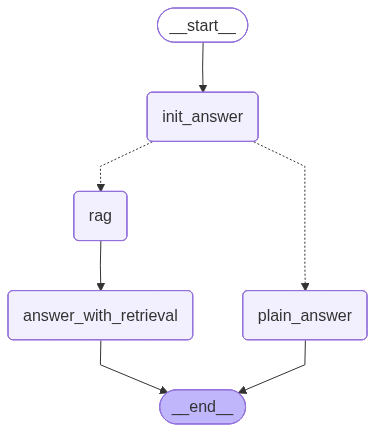

In [17]:
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇을 사용해봅시다.

**테스트 질문 예시**

- RAG 경로 (인공지능 산업 동향 연구 문서 활용)
  - 질문: "프런티어 모델 포럼에 대해 설명해"
  - 질문: "2023년 2분기 전 세계 AI 투자 규모는 얼마야?"
- 일반 답변 경로 (데이터 무관)
  - 질문: "오늘 저녁 뭐 먹을까?"

답변 생성에는 평균 20~30초 정도 소요됩니다.

In [18]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료' 입력): ")
    if question.strip() == "종료":
        break
    response = graph.invoke({"question": question})
    print("Assistant:", response["generation"])

[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: rag
[rag] Dense + BM25 하이브리드 검색 중...
[rag] Dense 5개 + BM25 5개 → rerank 이후 3개
[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...
[answer_with_retrieval] rerank 이후 top 3 문서:
  [0] - 7 -
[그림 2-3] 글로벌 AI 지수 상위 10개국의 전체 순위와 항목별 순위
출처 : Tortois Intelligence. The G
  [1] - 7 -
[그림 2-3] 글로벌 AI 지수 상위 10개국의 전체 순위와 항목별 순위
출처 : Tortois Intelligence. The G
  [2] - 8 -
[그림 2-4] 2019년~2023년 2분기 글로벌 AI 벤처 투자 추이
출처: CBInsights, State of AI Q2’23
Assistant: 2023년 2분기 전 세계 AI 투자 규모는 94억 달러입니다.
[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: plain_answer
[plain_answer] RAG 없이 답변 생성 중...
Assistant: 오늘 저녁으로는 어떤 음식을 드시고 싶으신가요? 한식, 중식, 양식, 일식 등 다양한 선택지가 있어요. 예를 들어, 비빔밥이나 김치찌개 같은 한식, 또는 파스타나 피자 같은 양식도 좋고, 초밥이나 라멘 같은 일식도 맛있죠. 기분이나 날씨에 따라 선택해 보세요!
